Group Members: Andrew Mankin, Ryan Safa

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.tree import plot_tree
layers = tf.keras.layers

Load the data and process

In [5]:
df = pd.read_csv("./dataset/labels.csv")

In [6]:
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Bad image:", path)
        return None

    img = cv2.resize(img, (224, 224))
    img = img.astype("float32") / 255.0
    #img = np.stack([img, img, img], axis=-1)
    return img

In [7]:
images = []
labels = []

for path, label in tqdm(zip(df["image"], df["label"]), total=len(df)):
    img = load_image(path)
    if img is None:
        continue
    images.append(img)
    labels.append(label)

X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=np.float32)

100%|██████████| 1734/1734 [04:14<00:00,  6.81it/s]


In [8]:
X = np.expand_dims(X, axis=-1)

Split the data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Check the data

In [10]:
# Verify the correct format
print(X_train.shape)
print(X_test.shape)

(1387, 224, 224, 1)
(347, 224, 224, 1)


In [11]:
# Flatten data for other techniques
X_train_flat = X_train.reshape(1387, -1)
X_test_flat = X_test.reshape(347, -1)
print(X_train_flat.shape)
print(X_test_flat.shape)

(1387, 50176)
(347, 50176)


## First Technique: CNN

In [12]:
# Model
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(224, 224, 1)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')  # binary classification
])

In [13]:
# Verify the model is correct
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,630,593 (21.48 MB)

 Trainable params: 5,630,593 (21.48 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
# Fit full dataset
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=8,
    batch_size=32
)

Epoch 1/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 779ms/step - accuracy: 0.5523 - loss: 0.6768 - val_accuracy: 0.5648 - val_loss: 0.6507
Epoch 2/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 813ms/step - accuracy: 0.5883 - loss: 0.6238 - val_accuracy: 0.5591 - val_loss: 0.6330
Epoch 3/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 806ms/step - accuracy: 0.6460 - loss: 0.5936 - val_accuracy: 0.6830 - val_loss: 0.6271
Epoch 4/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 804ms/step - accuracy: 0.7058 - loss: 0.5692 - val_accuracy: 0.7118 - val_loss: 0.6157
Epoch 5/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 803ms/step - accuracy: 0.7188 - loss: 0.5540 - val_accuracy: 0.7089 - val_loss: 0.6342
Epoch 6/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 801ms/step - accuracy: 0.7231 - loss: 0.5615 - val_accuracy: 0.7291 - val_loss: 0.6250
Epoch 7/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 831ms/step - accuracy: 0.7441 - loss: 0.5491 - val_accuracy: 0.7205 - val_loss: 0.6066
Epoch 8/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 31s 713ms/step - accuracy: 0.7397 - loss: 0.5333 - val_accuracy: 0.

In [16]:
y_pred_cnn = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step


In [17]:
y_pred_cnn_flat = (y_pred_cnn > 0.5).astype(int).flatten()

### 4 Performance Metrics

In [18]:
print("Accuracy:",accuracy_score(y_test, y_pred_cnn_flat))
print("Percision:",precision_score(y_test, y_pred_cnn_flat))
print("Recall:",recall_score(y_test, y_pred_cnn_flat))
print("F1 Score:",f1_score(y_test, y_pred_cnn_flat))

Accuracy: 0.7002881844380403
Percision: 0.6732673267326733
Recall: 0.7816091954022989
F1 Score: 0.723404255319149


 ### 3 Visualization Techniques

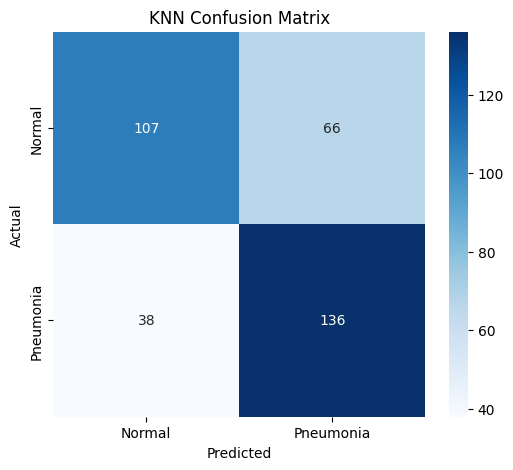

In [26]:
cm = confusion_matrix(y_test, y_pred_cnn_flat)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

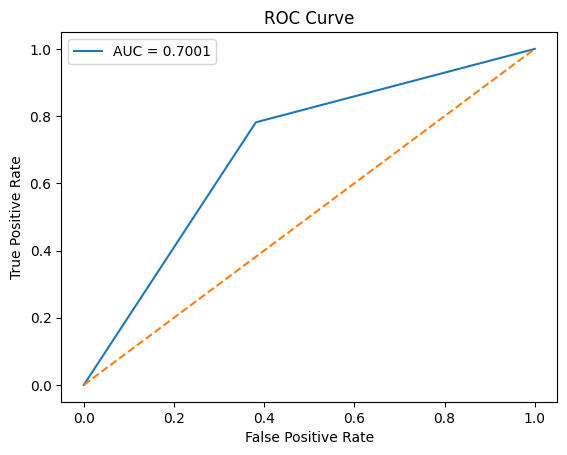

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_pred_cnn_flat)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

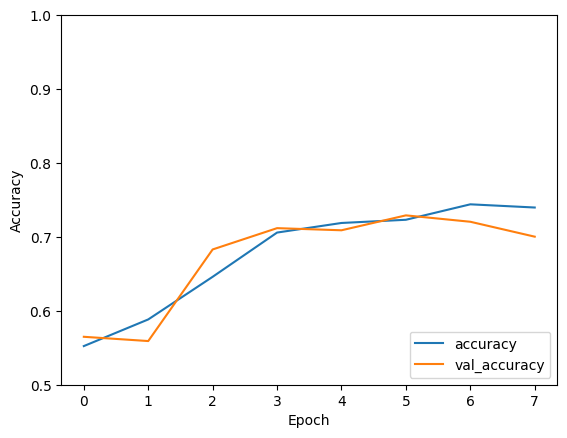

In [27]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

## Second Technique: KNN

In [29]:
knn = KNeighborsClassifier(n_neighbors=10, n_jobs=-1)
knn.fit(X_train_flat, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,-1


In [30]:
y_pred_knn = knn.predict(X_test_flat)

### 4 Performance Metrics

In [31]:
print("Accuracy:",accuracy_score(y_test, y_pred_knn))
print("Percision:",precision_score(y_test, y_pred_knn))
print("Recall:",recall_score(y_test, y_pred_knn))
print("F1 Score:",f1_score(y_test, y_pred_knn))

Accuracy: 0.7463976945244957
Percision: 0.7654320987654321
Recall: 0.7126436781609196
F1 Score: 0.7380952380952381


### 3 Visualization Techniques

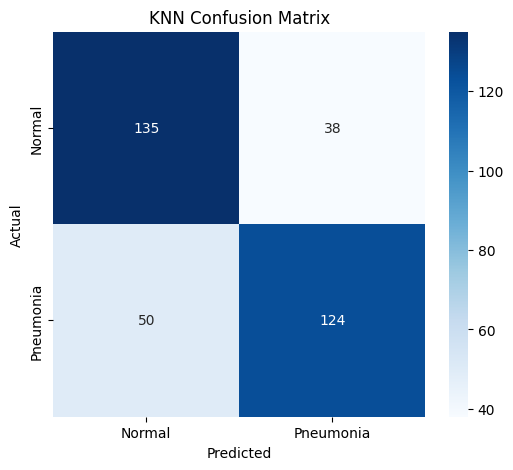

In [32]:
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

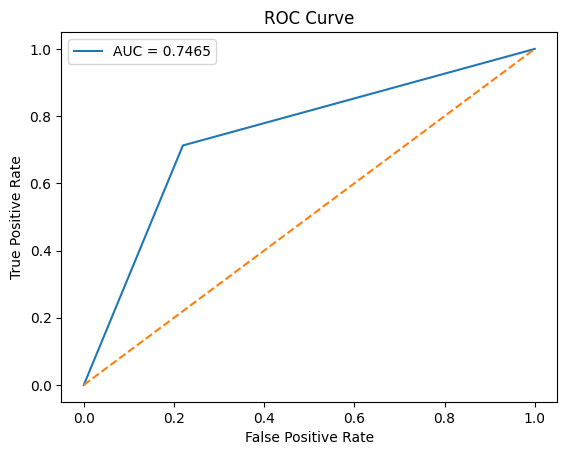

In [33]:
fpr, tpr, _ = roc_curve(y_test, y_pred_knn)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

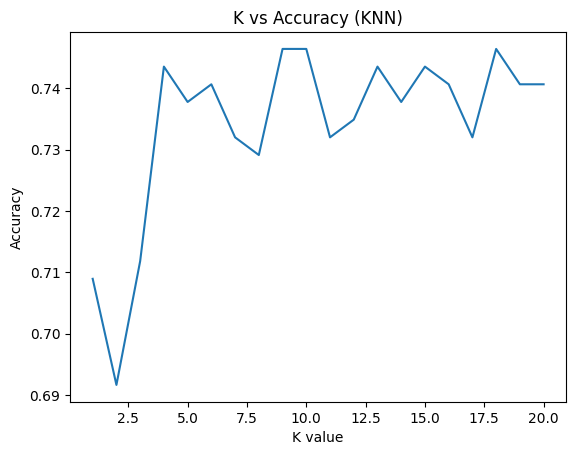

In [45]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_flat, y_train)
    y_pred = model.predict(X_test_flat)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy (KNN)")
plt.show()

## Third Technique: SVM

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

In [41]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [42]:
y_pred_svm = svm.predict(X_test_scaled)

### 4 Performance Metrics

In [43]:
print("Accuracy:",accuracy_score(y_test, y_pred_svm))
print("Percision:",precision_score(y_test, y_pred_svm))
print("Recall:",recall_score(y_test, y_pred_svm))
print("F1 Score:",f1_score(y_test, y_pred_svm))

Accuracy: 0.7002881844380403
Percision: 0.6804123711340206
Recall: 0.7586206896551724
F1 Score: 0.717391304347826


### 3 Visualization Techniques

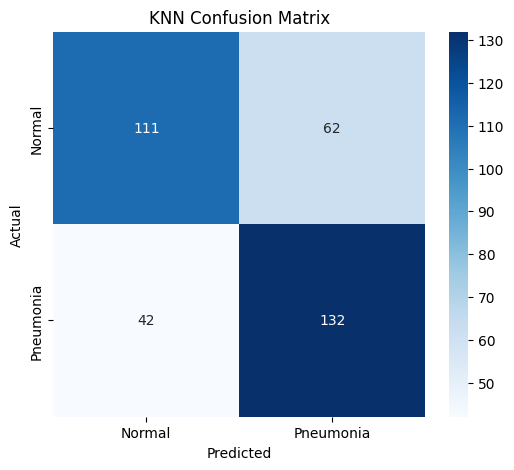

In [46]:
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

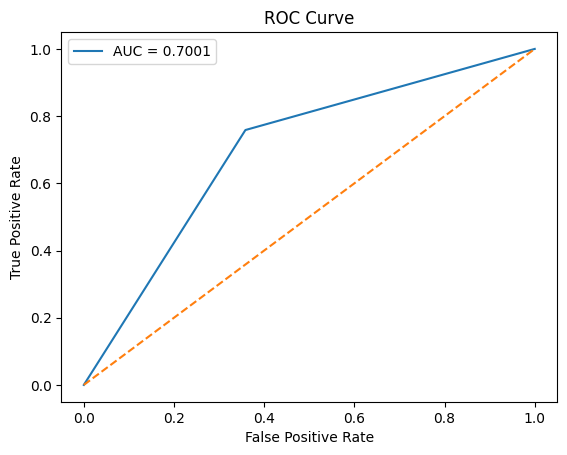

In [47]:
fpr, tpr, _ = roc_curve(y_test, y_pred_svm)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

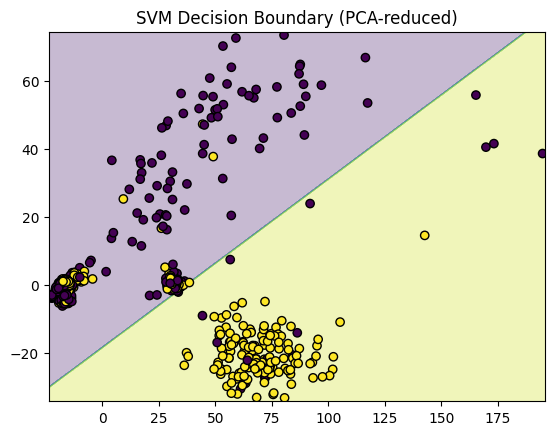

In [50]:
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_flat)
X_test_2d = pca.transform(X_test_flat)

svm = SVC(kernel='linear')
svm.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1
y_min, y_max = X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_2d[:,0], X_train_2d[:,1], c=y_train, edgecolor='k')
plt.title("SVM Decision Boundary (PCA-reduced)")
plt.show()

## Fourth Technique: Random Forests

In [34]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_flat, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred_rf = rf.predict(X_test_flat)

### 4 Performance Metrics

In [36]:
print("Accuracy:",accuracy_score(y_test, y_pred_rf))
print("Percision:",precision_score(y_test, y_pred_rf))
print("Recall:",recall_score(y_test, y_pred_rf))
print("F1 Score:",f1_score(y_test, y_pred_rf))

Accuracy: 0.7982708933717579
Percision: 0.8132530120481928
Recall: 0.7758620689655172
F1 Score: 0.7941176470588235


### 3 Visualization Techniques

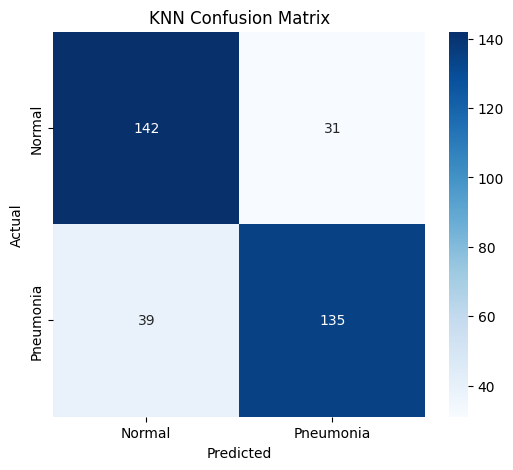

In [37]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

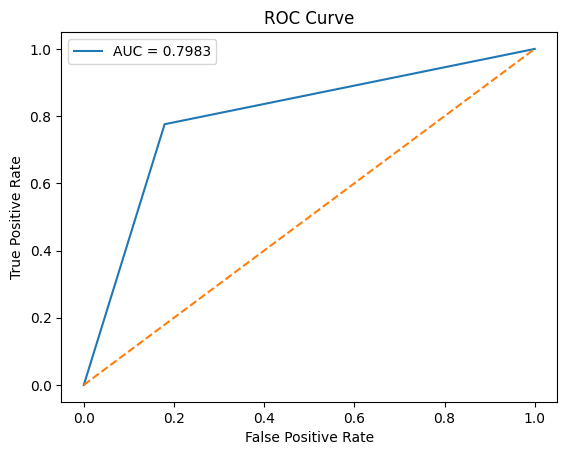

In [38]:
fpr, tpr, _ = roc_curve(y_test, y_pred_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

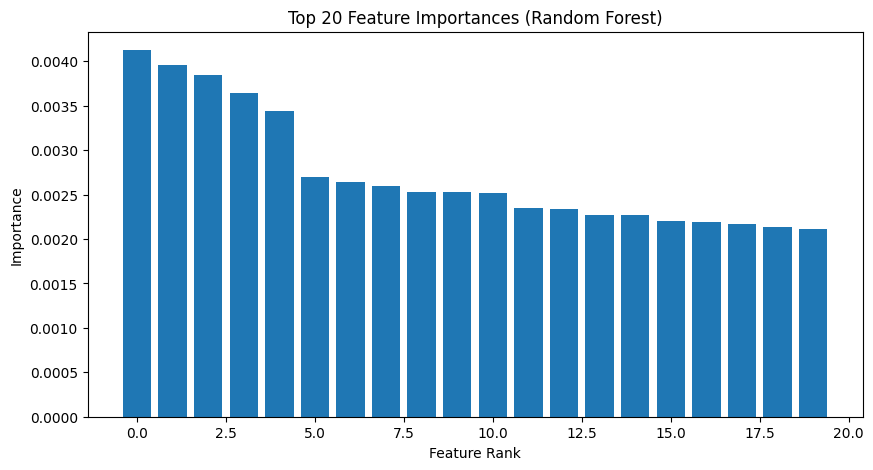

In [56]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.bar(range(20), importances[indices[:20]])
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Feature Rank")
plt.ylabel("Importance")
plt.show()